In [1]:
# Import all neccessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

## Data Cleaning

In [2]:
diabetic_data = pd.read_csv('diabetic_data.csv', header=0, encoding='utf-8')
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
diabetic_data.shape

(101766, 50)

In [4]:
diabetic_data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
# inspecting the dataset I realised that '?' is used as a placeholder for missing values
# replace those with nan to get the true state of missing values
diabetic_data.replace("?", np.nan, inplace=True)

In [7]:
"""
For a medical diagnostics dataset specifically curated to predict diabetes
reoccurance I find it quite strange that a key attribute such as weight which
has been scientifically linked to diabetes has so many missing values. In an
industry setting I would recommend that the dataset is unusable. But for the
sake of academic work I guess we could proceed.
"""

diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
]

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

In [8]:
"""
Looking at the proportion of missing values we can derive some more insight into
the quality of data collected. 96% of weight data is missing, essentially rendering that
column unusable for modeling purposes. There are imputation techniques to use when
dealing with missing values but I am more comfortable using them when there are only
few missing values. If we use imputation on an attribute with say 50% missing values
then we severly damage the integrity of the data since 50% of values in that column
is essentially guessed.

Now if there is a trend in that column, say values are typically within a specific range
then perharps our imputations won't be too far off but in this case, I would recommend
dropping all columns with >50% missing values. Please check if it is the same on your
end.

Also columns such as payer_code and medical_specialty in my opinion have nothing to do
with a person's disease, these should be dropped as well. Race has just 2% missing values,
we can input them with the most frequently occuring race in the dataset. Same will be done
for diag_1 - 3.
"""

diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
] * (100/diabetic_data.shape[0])

race                  2.233555
weight               96.858479
payer_code           39.557416
medical_specialty    49.082208
diag_1                0.020636
diag_2                0.351787
diag_3                1.398306
max_glu_serum        94.746772
A1Cresult            83.277322
dtype: float64

In [9]:
to_drop = [
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
    ]

diabetic_data.drop(to_drop, axis=1, inplace=True)

In [10]:
# fill with mode
to_fill = ["race", "diag_1", "diag_2", "diag_3"]

for col in to_fill:
  modal_value = diabetic_data[col].mode().item()
  missing_index = diabetic_data.race[diabetic_data[col].isnull()].index

  for idx in missing_index:
    diabetic_data.loc[idx, col] = modal_value

In [11]:
# check

diabetic_data.isnull().sum()[
    diabetic_data.isnull().sum() > 0
]

Series([], dtype: int64)

In [12]:
"""
To make things easier we should map the age bins to numeric values
"""

age_bins_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

diabetic_data["age"] = diabetic_data["age"].map(age_bins_mapping)

## Handle Class Imbalance

In [13]:
diabetic_data.readmitted.unique()

array(['NO', '>30', '<30'], dtype=object)

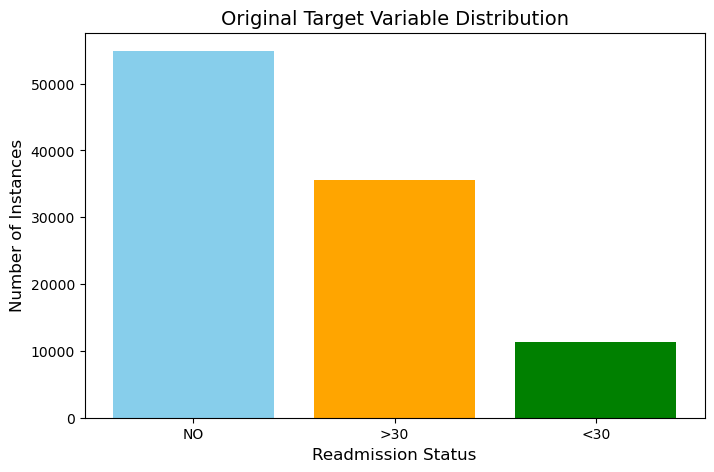

In [14]:
# Visualize original class distribution
original_counts = diabetic_data['readmitted'].value_counts()
classes = original_counts.index
counts = original_counts.values

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['skyblue', 'orange', 'green'])
plt.title('Original Target Variable Distribution', fontsize=14)
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [15]:
"""
The mapping done below essentialy converts the modeling task into a binary
classification task where we want to predict if an individual is readmitted within 30 days.
"""
target_mapping = {
    "NO": 0,
    ">30": 0,
    "<30": 1
}

diabetic_data["readmitted"] = diabetic_data["readmitted"].map(target_mapping)

In [16]:
diabetic_data.readmitted.value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

In [17]:
"""
To handle the minor class imbalance in the dataset, randomly undersample class 0
(not readmitted) to match the number of class 1 instances
"""

random_idx = np.random.randint(90409, size=11357)
random_sample = diabetic_data.query("readmitted == 0").iloc[random_idx]

diabetic_data = pd.concat(
    (diabetic_data.query("readmitted == 1"), random_sample),
    axis=0
)

In [18]:
# check
diabetic_data.readmitted.value_counts()

readmitted
1    11357
0    11357
Name: count, dtype: int64

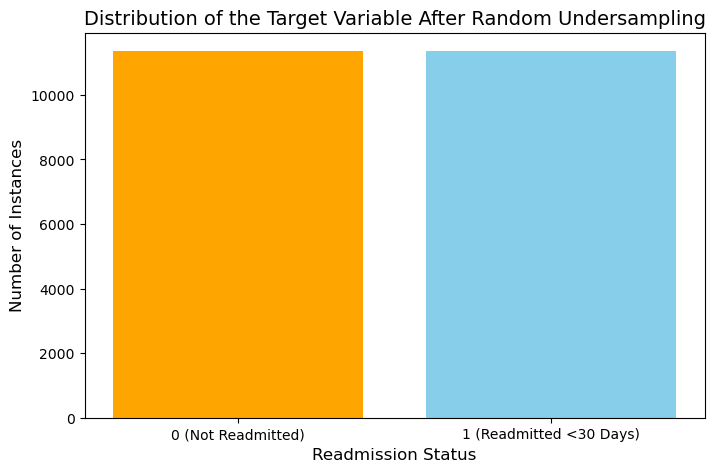

In [19]:
# Assume `undersampled_data` contains the dataset after random undersampling
undersampled_counts = diabetic_data['readmitted'].value_counts()
classes = undersampled_counts.index
counts = undersampled_counts.values

# Plot the class distribution after random undersampling
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['skyblue', 'orange'])
plt.title('Distribution of the Target Variable After Random Undersampling', fontsize=14)
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Not Readmitted)', '1 (Readmitted <30 Days)'], fontsize=10)
plt.show()


## Handle Column Cardinality

In [20]:
def check_column_cardinality(df):
  count_dict = dict()
  for col in df.columns:
    count_dict[col] = len(df[col].unique())
  return count_dict

In [21]:
# filter for numerical and categorical columns
numerical_columns = [
    x for x in diabetic_data.columns if diabetic_data[x].dtype != "object"
    ]
categorical_columns = [
    x for x in diabetic_data.columns if diabetic_data[x].dtype == "object"
]

In [22]:
"""
High cardinality columns are not good for modelling as they significantly increase
the number of columns when encoded.
"""
check_column_cardinality(diabetic_data)

{'encounter_id': 21997,
 'patient_nbr': 17611,
 'race': 5,
 'gender': 2,
 'age': 10,
 'admission_type_id': 8,
 'discharge_disposition_id': 24,
 'admission_source_id': 12,
 'time_in_hospital': 14,
 'num_lab_procedures': 108,
 'num_procedures': 7,
 'num_medications': 72,
 'number_outpatient': 29,
 'number_emergency': 24,
 'number_inpatient': 20,
 'diag_1': 544,
 'diag_2': 539,
 'diag_3': 573,
 'number_diagnoses': 16,
 'metformin': 4,
 'repaglinide': 4,
 'nateglinide': 4,
 'chlorpropamide': 3,
 'glimepiride': 4,
 'acetohexamide': 1,
 'glipizide': 4,
 'glyburide': 4,
 'tolbutamide': 2,
 'pioglitazone': 4,
 'rosiglitazone': 4,
 'acarbose': 4,
 'miglitol': 3,
 'troglitazone': 1,
 'tolazamide': 2,
 'examide': 1,
 'citoglipton': 1,
 'insulin': 4,
 'glyburide-metformin': 4,
 'glipizide-metformin': 2,
 'glimepiride-pioglitazone': 1,
 'metformin-rosiglitazone': 1,
 'metformin-pioglitazone': 1,
 'change': 2,
 'diabetesMed': 2,
 'readmitted': 2}

In [23]:
# these are high cardinality and are id columns and they can be dropped
diabetic_data.drop(
    [
        "encounter_id",
        "patient_nbr",
    ],
    axis=1,
    inplace=True
)

## Feature Selection

In [24]:
def ordinal_encode(df, encoder):
  categoricals = [
    x for x in df.columns if df[x].dtype == "object"
  ]
  encoded = encoder.fit_transform(df[categoricals])
  df[categoricals] = encoded
  return df

In [25]:
ordinal_encoder = OrdinalEncoder()

df_ord = ordinal_encode(diabetic_data, ordinal_encoder)
df_ord.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
11,0.0,1.0,6,2,1,4,7,62,0,11,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
12,2.0,0.0,4,1,3,7,7,60,0,15,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
16,0.0,1.0,5,1,1,7,4,45,4,17,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
46,2.0,0.0,7,3,5,4,9,25,3,16,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
50,0.0,1.0,5,2,1,2,4,40,1,14,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [26]:
X = df_ord.drop("readmitted", axis=1)
y = df_ord["readmitted"]
mi_scores = mutual_info_classif(X, y, random_state=0)
mi_scores = pd.Series(mi_scores, index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores[:10]

number_inpatient            0.028242
discharge_disposition_id    0.021283
diag_2                      0.015176
diag_1                      0.012093
tolazamide                  0.007585
diabetesMed                 0.007507
diag_3                      0.006648
metformin                   0.006311
number_diagnoses            0.006080
acetohexamide               0.005975
dtype: float64

<Axes: >

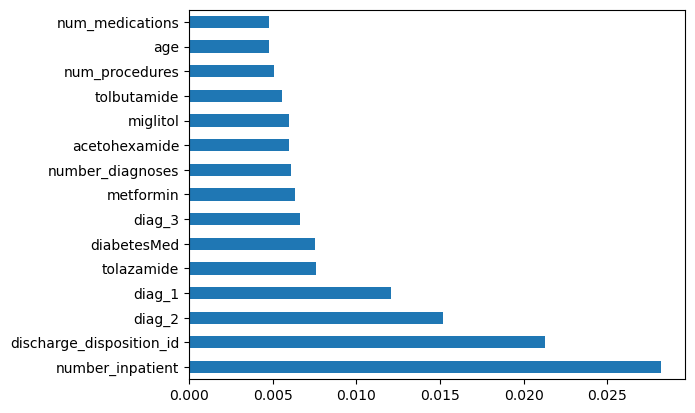

In [27]:
mi_scores[:15].plot(kind="barh")

In [28]:
"""
Looking at the plots, there seems to be a dropoff in MI scores after the 9th
feature. The first 9 highest scoring features are selected.
"""
selected_features = mi_scores.index[:5]
selected_features

Index(['number_inpatient', 'discharge_disposition_id', 'diag_2', 'diag_1',
       'tolazamide'],
      dtype='object')

## Model Building

In [29]:
def one_hot_encode(df, encoder):
  encoded = encoder.fit_transform(df).toarray()
  column_headers = list(encoder.get_feature_names_out())

  temp_df = pd.DataFrame(encoded, columns=column_headers)
  return temp_df

In [30]:
oh_encoder = OneHotEncoder(handle_unknown="ignore")
X = one_hot_encode(diabetic_data[selected_features], oh_encoder)
y = diabetic_data["readmitted"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [31]:
def train_model(
    model, x_train, y_train, x_val, y_val
):
  model.fit(x_train, y_train)
  y_pred = model.predict(X_val)
  cm = confusion_matrix(y_val, y_pred)
  print("Accuracy:", accuracy_score(y_val, y_pred))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  print("Classification Report:\n", classification_report(y_val, y_pred))

/Users/chivic/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.6218357913273167
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.64      2263
           1       0.63      0.58      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



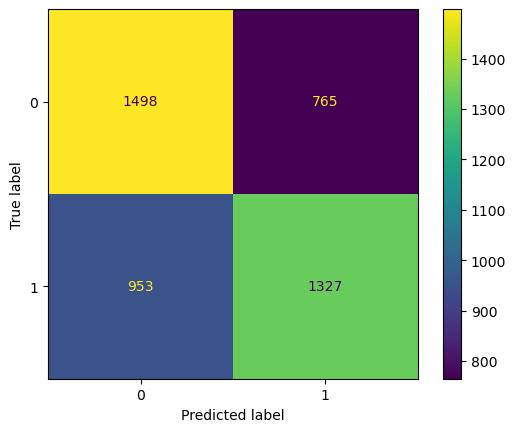

In [32]:
model = LogisticRegression(random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.6222760290556901
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.64      2263
           1       0.63      0.58      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



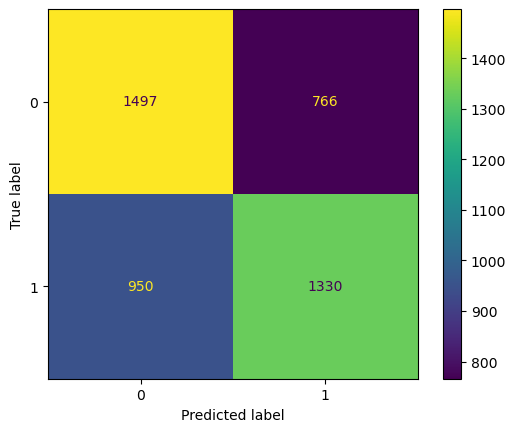

In [33]:
model = LogisticRegression(max_iter=1000, random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.6224961479198767
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.64      2263
           1       0.63      0.58      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



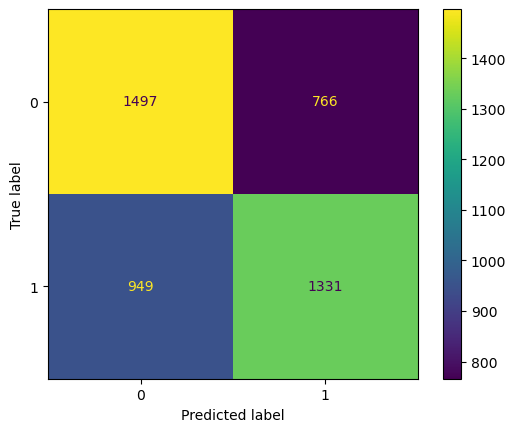

In [34]:
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.6224961479198767
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.64      2263
           1       0.63      0.58      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



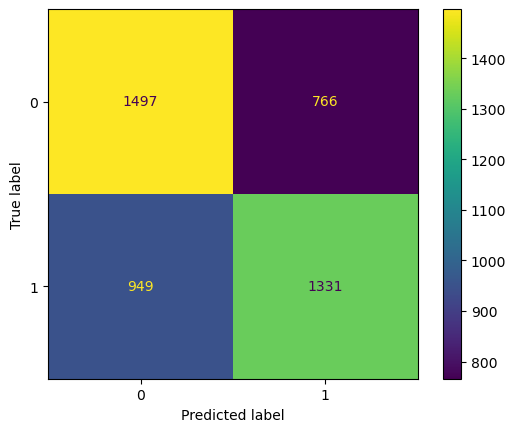

In [35]:
rf_model = RandomForestClassifier(random_state=0)

train_model(
    model, X_train, y_train, X_val, y_val
)

Accuracy: 0.6216156724631301
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.65      0.63      2263
           1       0.63      0.59      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



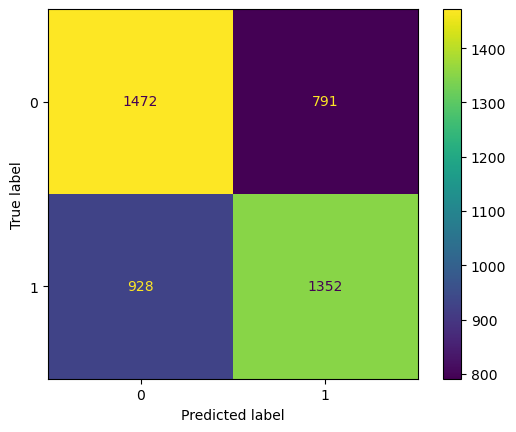

In [37]:
xgb_model = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')

train_model(
    xgb_model, X_train, y_train, X_val, y_val
)

Accuracy: 0.6222760290556901
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.65      0.63      2263
           1       0.63      0.59      0.61      2280

    accuracy                           0.62      4543
   macro avg       0.62      0.62      0.62      4543
weighted avg       0.62      0.62      0.62      4543



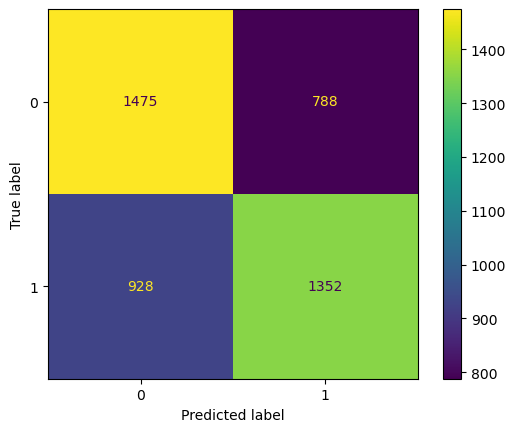

In [38]:
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    final_estimator=LogisticRegression(random_state=0)
)

train_model(
    stacking_model, X_train, y_train, X_val, y_val
)